<a href="https://colab.research.google.com/github/ilya-agafonov/dsp-seminars/blob/agafonov_lab5/seminars/5_Agafonov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №5
## Основные характеристики цифровых фильтров

## Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, savgol_coeffs, group_delay
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Вспомогательная функция для построения частотных характеристик
def plot_filter_response(b, a, fs=1000, title=''):
    """Строит АЧХ (линейный и дБ), ФЧХ и групповую задержку фильтра"""
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20*np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H))
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    plt.figure(figsize=(12,10))
    plt.subplot(4,1,1)
    plt.semilogy(w, np.abs(H))
    plt.title(f'АЧХ (линейный масштаб) – {title}')
    plt.grid()
    plt.subplot(4,1,2)
    plt.plot(w, mag_dB)
    plt.title('АЧХ (дБ)')
    plt.ylabel('|H| (дБ)')
    plt.grid()
    plt.subplot(4,1,3)
    plt.plot(w, phase)
    plt.title('ФЧХ')
    plt.ylabel('Фаза (рад)')
    plt.grid()
    plt.subplot(4,1,4)
    plt.plot(w_gd, gd)
    plt.title('Групповая задержка')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Задержка (отсчёты)')
    plt.grid()
    plt.tight_layout()
    plt.show()


## Часть 1. КИХ-фильтр: скользящее среднее

**Скользящее среднее** – простейший КИХ-фильтр. Его коэффициенты: `b_k = 1/M` для `k = 0,...,M-1`. Фильтр имеет линейную фазу.

### Задание 1.1. Импульсная и переходная характеристики

Для длины окна `M = 5`:
1. Сформируйте массив коэффициентов `b` (нормированный).
2. Создайте тестовые сигналы: единичный импульс (длиной 20 отсчётов) и единичный скачок (длиной 50 отсчётов).
3. Примените фильтр с помощью `signal.lfilter(b, a, x)`, где `a = [1]`.
4. Постройте импульсную и переходную характеристики.


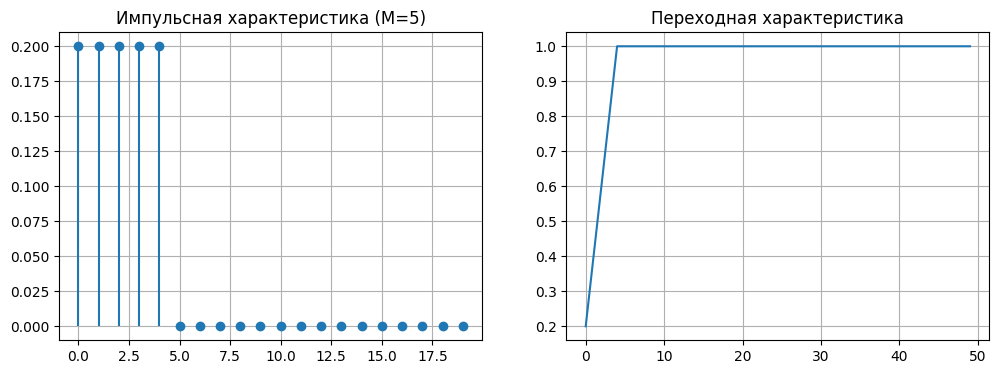

In [2]:
# Ваш код здесь
M = 5
# Ваш код здесь: создать массивы b и a
b = np.ones(M) / M
a = [1]

# Импульс
impulse = np.zeros(20)
impulse[0] = 1

# Ваш код здесь: вычислить h = signal.lfilter(...)
h = signal.lfilter(b, a, impulse)

# Скачок
step = np.ones(50)

# Ваш код здесь: вычислить s = signal.lfilter(...)
s = signal.lfilter(b, a, step)

# Построение
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")   # Ваш код здесь: подставить h
plt.title(f'Импульсная характеристика (M={M})')
plt.grid()

plt.subplot(1,2,2)
plt.plot(s)                # Ваш код здесь: подставить s
plt.title('Переходная характеристика')
plt.grid()
plt.show()


**Вопрос:** Почему импульсная характеристика имеет конечную длину, а переходная выходит на постоянный уровень?


**Ответ:** Импульсная характеристика имеет конечную длину, потому что это КИХ-фильтр, при выход за длину M остаются нули и выход фильтра обнуляется. Переходная характеристика выходит на постоянный уровень, потому что когда все M позиций заполняются единицами входного скачка и их среднее значение равняеися 1

### Задание 1.2. АЧХ и ФЧХ

Используя функцию `plot_filter_response`, постройте характеристики для скользящего среднего с длинами окон `M = 5`, `M = 10`, `M = 20`.


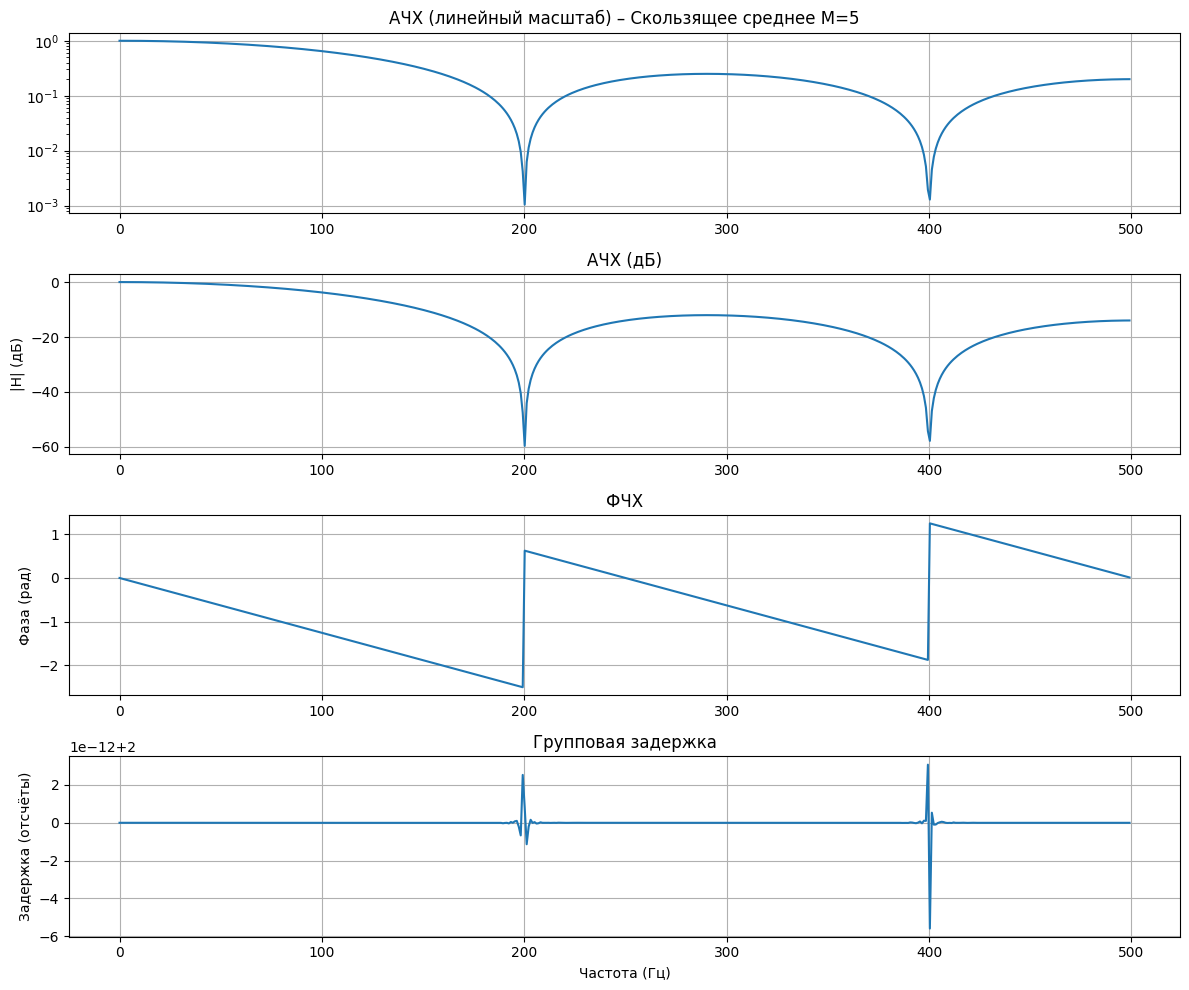

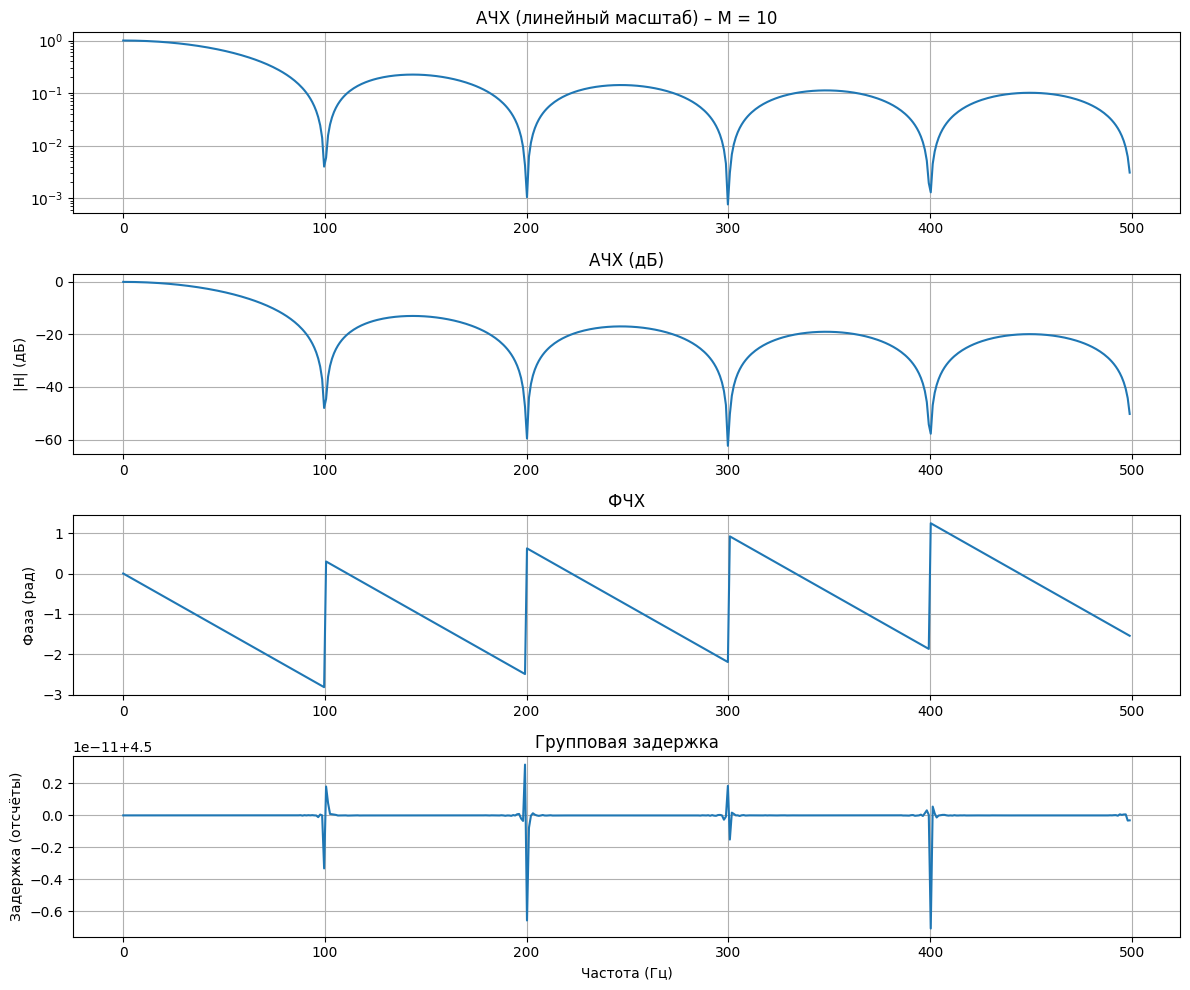

/tmp/ipykernel_1381/3306243778.py:17: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), fs=fs)


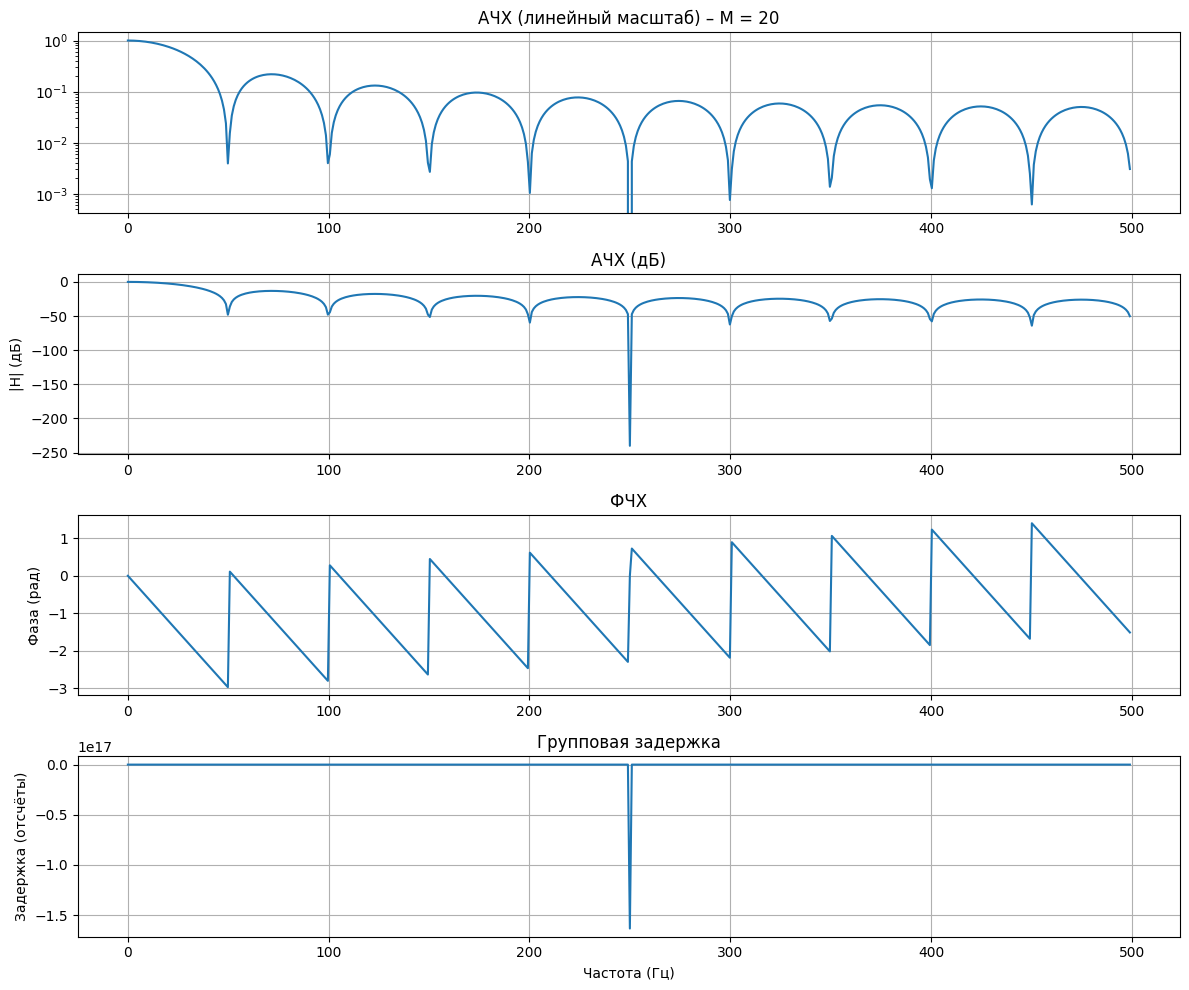

In [5]:
# Для M=5
b5 = np.ones(5)/5
plot_filter_response(b5, [1], fs=1000, title='Скользящее среднее M=5')

# Ваш код здесь: повторить для M=10 и M=20
b10 = np.ones(10) / 10
b20 = np.ones(20) / 20
a = [1]
plot_filter_response(b10, a, fs=1000, title='M = 10')
plot_filter_response(b20, a, fs=1000, title='M = 20')

**Вопрос:** Как изменение `M` влияет на крутизну среза АЧХ и на ФЧХ?


**Ответ:**  Крутизна среза АЧХ. При увеличении M основной лепесток АЧХ становится уже, а крутизна спада в зоне перехода выше. Фильтр начинает подавлять более низкие частоты


Крутизна среза ФЧХ. При увеличении M наклон ФЧХ становится круче. Это значит, что увеличивается групповая задержка сигнала

### Задание 1.3. Фильтрация суммы синусоид

Сгенерируйте сигнал длительностью 1 с (fs=1000 Гц): `x = sin(2π·10·t) + 0.5·sin(2π·100·t)`. Примените скользящее среднее с `M=5` и `M=20`. Постройте временные графики и спектры (амплитудный спектр через БПФ).


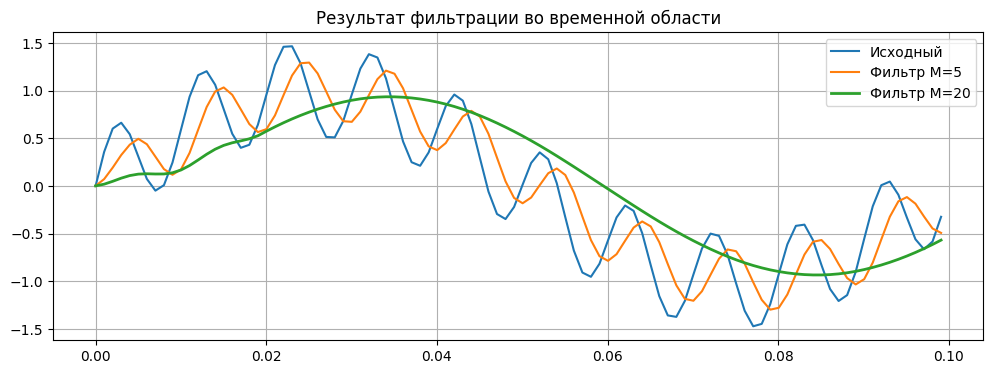

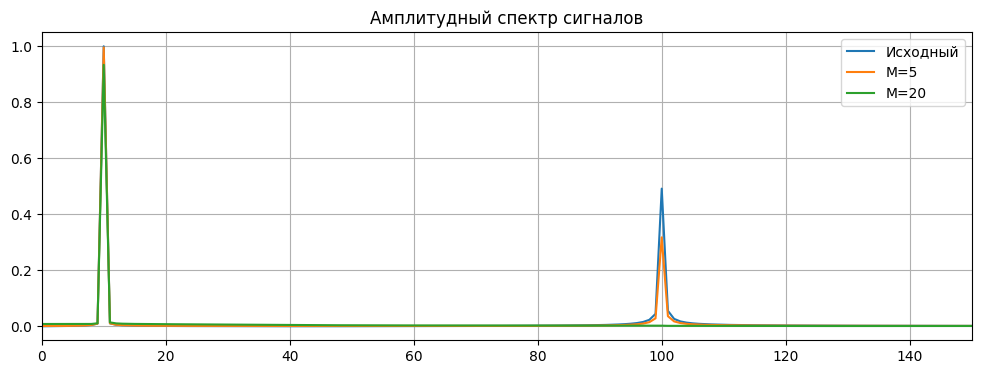

In [ ]:
fs = 1000
t = np.linspace(0, 1, fs)
x = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*100*t)

# Ваш код здесь: фильтрация с M=5 и M=20
y5 = signal.lfilter(np.ones(5)/5, [1], x)
y20 = signal.lfilter(np.ones(20)/20, [1], x)

# Временные графики (первые 100 отсчётов)
plt.figure(figsize=(12,4))
plt.plot(t[:100], x[:100], label='Исходный')
# Ваш код здесь: добавить графики y5, y20
plt.plot(t[:100], y5[:100], label='Фильтр M=5')
plt.plot(t[:100], y20[:100], label='Фильтр M=20', linewidth=2)
plt.title('Результат фильтрации во временной области')
plt.legend()
plt.grid()
plt.show()

# Спектры
def plot_spectrum(s, label):
    X = np.fft.fft(s)
    freq = np.fft.fftfreq(len(s), 1/fs)
    plt.plot(freq[:len(freq)//2], np.abs(X[:len(freq)//2])/(len(s)//2), label=label)

plt.figure(figsize=(12,4))
plot_spectrum(x, 'Исходный')
# Ваш код здесь: добавить спектры y5, y20
plot_spectrum(y5, 'M=5')
plot_spectrum(y20, 'M=20')
plt.title('Амплитудный спектр сигналов')
plt.xlim(0, 150)
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Как значение `M` влияет на амплитуду 100 Гц сигнала? Объясните, почему так. Какая связь между АЧХ и результатом фильтрации?


**Ответ:** При M=5 амплитуда сигнала 100 Гц уменьшается, но он остается виден на спектре. При M=20 сигнал частотой 100 Гц полностью исчезает. Нули АЧХ скользящего среднего расположены на частотах кратных $f_s$ / M.

Связь с АЧХ: Результат фильтрации на конкретной частоте равно произведению входной амплитуды на АЧХ $|H(f)|$ на этой частоте

## Часть 2. БИХ-фильтр: экспоненциальное сглаживание

Фильтр первого порядка: `y[n] = α x[n] + (1-α) y[n-1]`. Коэффициенты: `b = [α]`, `a = [1, -(1-α)]`.

### Задание 2.1. Реализация и характеристики

Для `α = 0.2`:
1. Постройте импульсную характеристику (50 отсчётов) и переходную характеристику.
2. Используя `plot_filter_response`, постройте АЧХ, ФЧХ и групповую задержку.


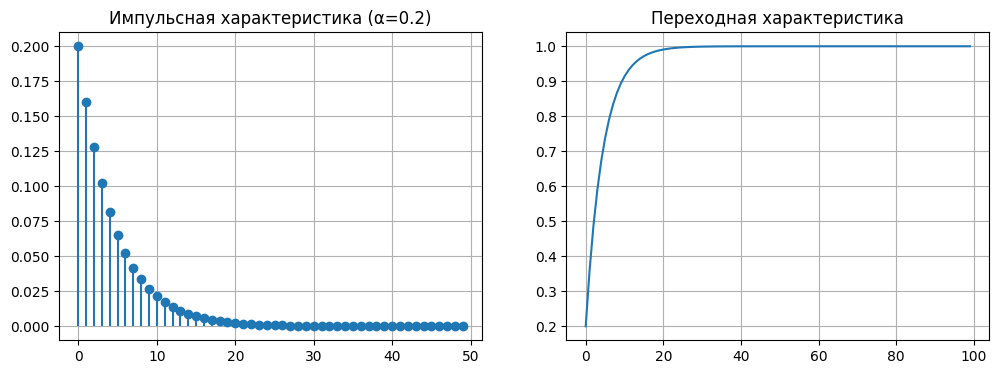

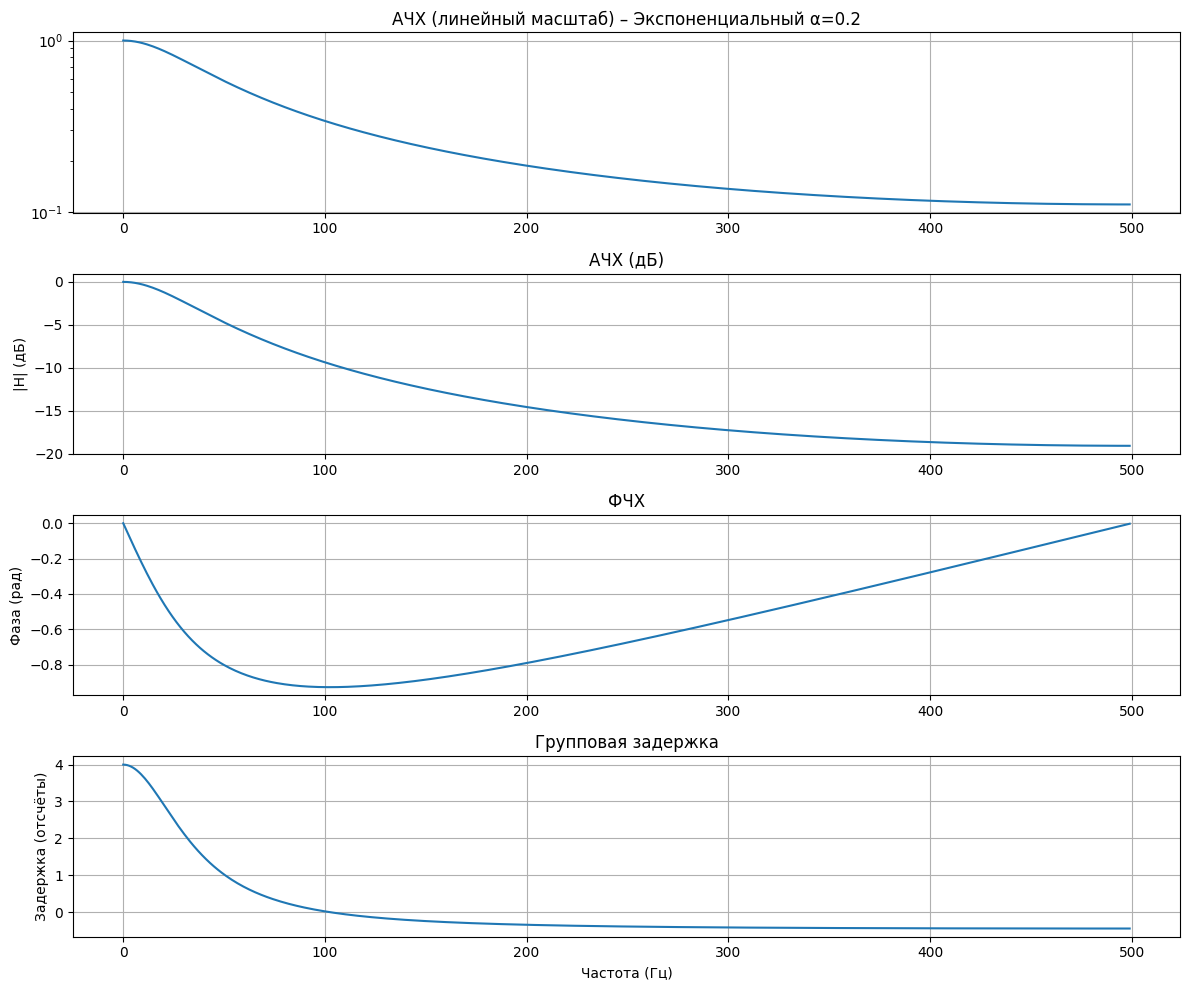

In [6]:
alpha = 0.2
b = [alpha]
a = [1, -(1-alpha)]

# Импульсная характеристика (длина 50)
impulse = np.zeros(50)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)
# Переходная характеристика (длина 100)
step = np.ones(100)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (α={alpha})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()

# Частотные характеристики
plot_filter_response(b, a, fs=1000, title=f'Экспоненциальный α={alpha}')


### Задание 2.2. Влияние параметра α

Исследуйте фильтр при `α = 0.05, 0.2, 0.8`. Постройте на одном графике АЧХ (в дБ) и на другом – групповую задержку. Сделайте выводы.


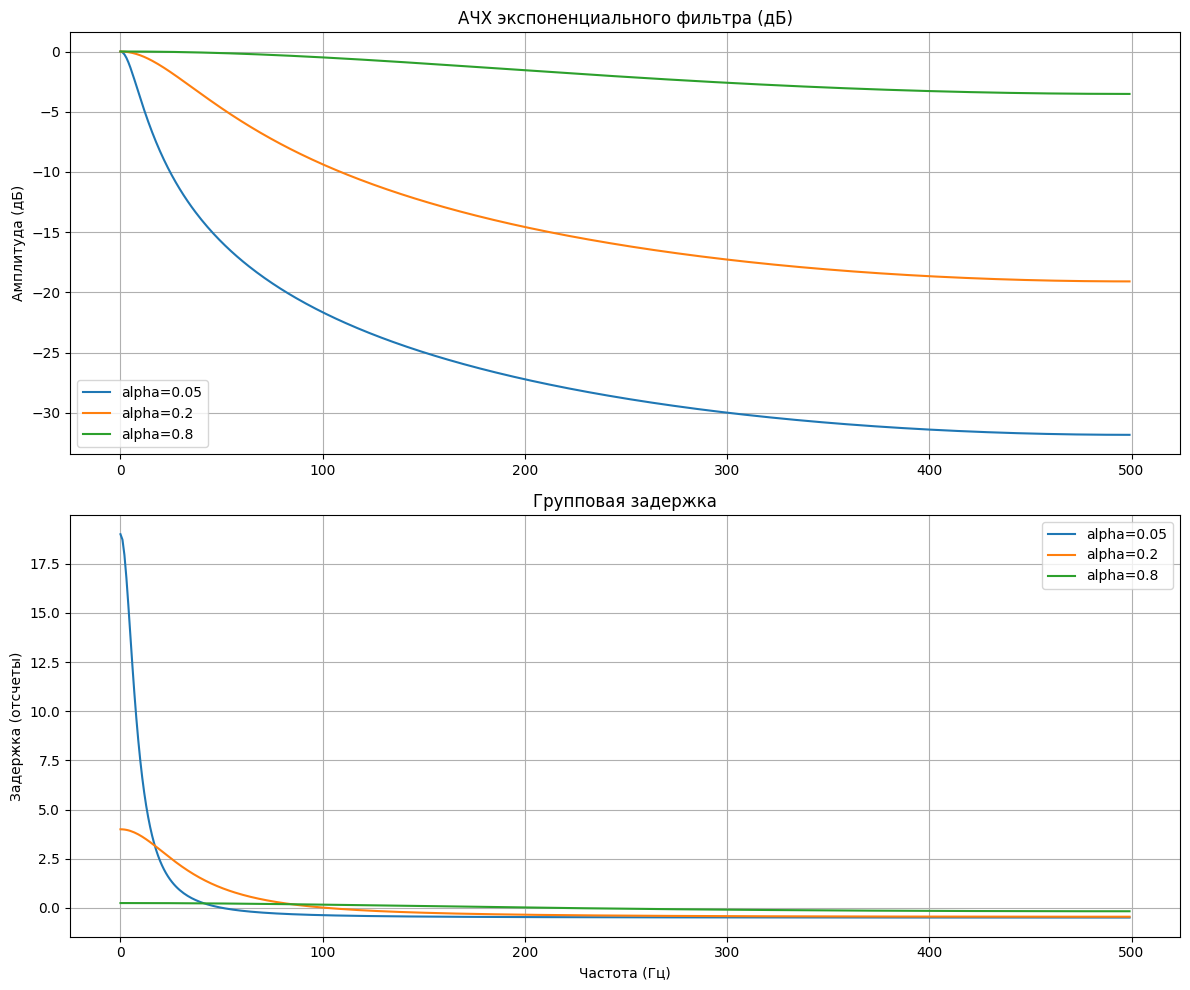

In [12]:
alphas = [0.05, 0.2, 0.8]
# Ваш код здесь: построить АЧХ (в дБ) и групповую задержку для всех α

plt.figure(figsize=(12, 10))
for a_val in alphas:
    b = [a_val]
    a = [1, -(1 - a_val)]

    w, H = signal.freqz(b, a, fs=1000)
    w_gd, gd = signal.group_delay((b, a), fs=1000)

    plt.subplot(2, 1, 1)
    plt.plot(w, 20*np.log10(np.abs(H) + 1e-12), label=f'alpha={a_val}')
    plt.subplot(2, 1, 2)
    plt.plot(w_gd, gd, label=f'alpha={a_val}')

plt.subplot(2, 1, 1)
plt.title('АЧХ экспоненциального фильтра (дБ)')
plt.ylabel('Амплитуда (дБ)')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчеты)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Вопрос:** Как α влияет на скорость реакции фильтра на изменение сигнала и на крутизну спада АЧХ?


**Ответ:** Чем меньше α, тем сильнее сглаживание и медленнее фильтр реагирует на изменения. При α=0.05 задержка самая большая. Экспоненциальный фильтр это фильтр 1-го порядка. Уменьшение α не меняет крутизну, а сдвигает частоту среза ниже


### Задание 2.3. Фильтрация зашумлённого сигнала

Сгенерируйте сигнал: синусоида 20 Гц + белый шум (SNR ≈ 5 дБ), fs=500 Гц. Примените экспоненциальный фильтр с α = 0.1 и α = 0.5. Постройте исходный и отфильтрованные сигналы (первые 0.2 с). Сравните степень сглаживания и задержку.


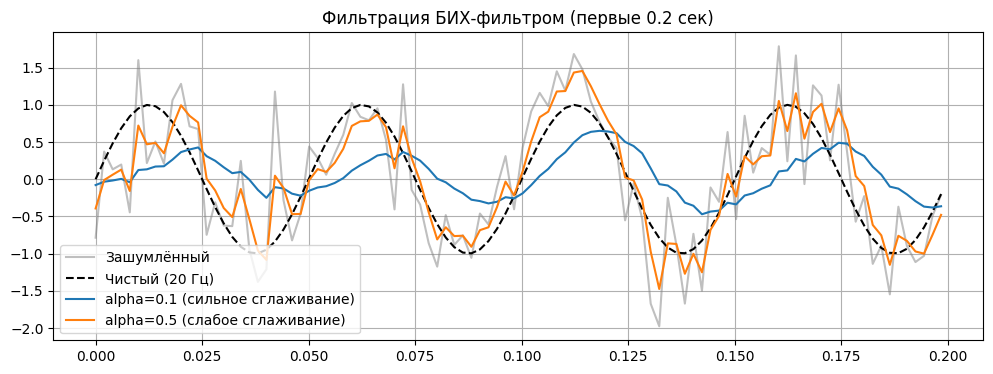

In [13]:
fs = 500
t = np.linspace(0, 1, fs)
x_clean = np.sin(2*np.pi*20*t)
noise = 0.5 * np.random.randn(len(t))
x_noisy = x_clean + noise

# Ваш код здесь: фильтрация с alpha=0.1 и alpha=0.5

y01 = signal.lfilter([0.1], [1, -0.9], x_noisy)
y05 = signal.lfilter([0.5], [1, -0.5], x_noisy)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x_noisy[:100], 'gray', alpha=0.5, label='Зашумлённый')
# Ваш код здесь: добавить графики отфильтрованных сигналов
plt.plot(t[:100], x_clean[:100], 'k--', label='Чистый (20 Гц)')
plt.plot(t[:100], y01[:100], label='alpha=0.1 (сильное сглаживание)')
plt.plot(t[:100], y05[:100], label='alpha=0.5 (слабое сглаживание)')
plt.title('Фильтрация БИХ-фильтром (первые 0.2 сек)')
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Как на временных графиках проявляется групповая задержка, вносимая БИХ-фильтром?


**Ответ:** Групповая задержка проявляется как сдвиг фазы отфильтрованного сигнала относительно исходного. На графике пики синусоиды после фильтрации при α=0.1 наступают позже, чем у исходной синусоиды. Чем меньше α, тем сильнее этот временной сдвиг.


## Часть 3. Фильтр Савицкого – Голея (Savitzky–Golay)

Этот КИХ-фильтр основан на локальной полиномиальной регрессии. Он сохраняет форму сигнала (пики, перегибы) лучше, чем скользящее среднее.

### Задание 3.1. Базовое применение и влияние параметров

Сгенерируйте синусоиду 5 Гц (fs=100 Гц, длительность 2 с) и добавьте белый шум (дисперсия 0.2). Примените `savgol_filter` с параметрами:
- (window=11, polyorder=2)
- (window=21, polyorder=2)
- (window=11, polyorder=5)

Постройте исходный чистый сигнал, зашумлённый и три сглаженные версии. Объясните влияние параметров.


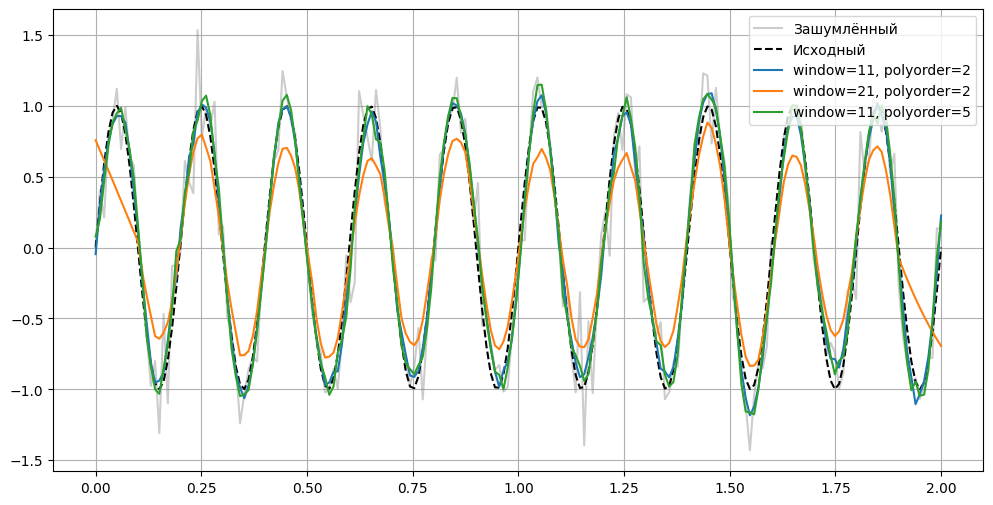

In [16]:
fs = 100
t = np.linspace(0, 2, 2*fs)
x_clean = np.sin(2*np.pi*5*t)
noise = 0.2 * np.random.randn(len(t))
x_noisy = x_clean + noise

# Ваш код здесь: применить savgol_filter с разными параметрами
y1 = savgol_filter(x_noisy, window_length=11, polyorder=2)
y2 = savgol_filter(x_noisy, window_length=21, polyorder=2)
y3 = savgol_filter(x_noisy, window_length=11, polyorder=5)


plt.figure(figsize=(12,6))
plt.plot(t, x_noisy, 'gray', alpha=0.4, label='Зашумлённый')
plt.plot(t, x_clean, 'k--', label='Исходный')
# Ваш код здесь: добавить графики y1, y2, y3
plt.plot(t, y1, label='window=11, polyorder=2')
plt.plot(t, y2, label='window=21, polyorder=2')
plt.plot(t, y3, label='window=11, polyorder=5')
plt.legend()
plt.grid()
plt.show()


**Вопрос 3.1:** Как увеличение `window_length` и увеличение `polyorder` влияют на степень сглаживания и сохранение формы сигнала?


**Ответ:** При увеличении window_length степень сглаживания растет. Фильтр учитывает больше соседних точек, случайные всплески шума усредняются эффективнее и линия становится более плавной. Высокий порядок полинома лучше сохраняет форму сигнала, потому что полином 5-й степени точнее описывает изгиб синусоиды, чем простая парабола 2-й степени.


### Задание 3.2. Сравнение со скользящим средним

Создайте сигнал с острым пиком (гауссов импульс с σ=3) на фоне шума. Примените скользящее среднее (window=11) и Savitzky–Golay (window=11, polyorder=2). Сравните, какой фильтр лучше сохраняет форму пика.


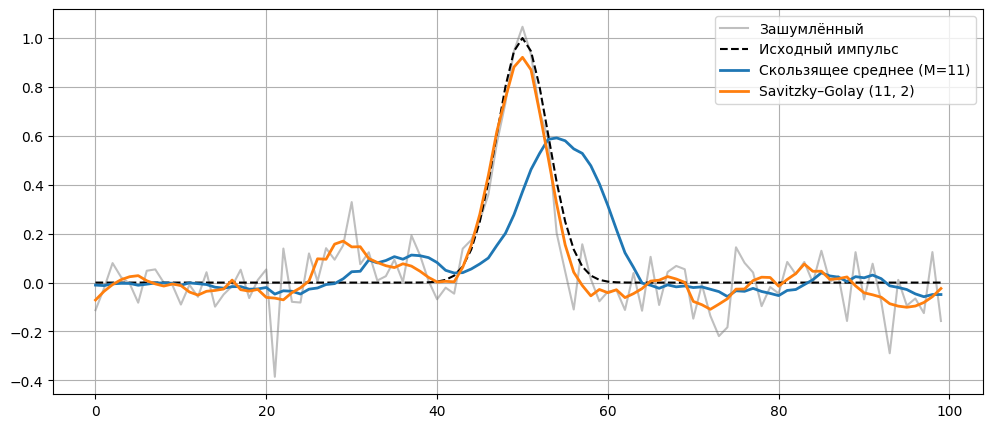

In [19]:
# Генерация гауссова импульса
N = 100
x_pulse = np.zeros(N)
x_pulse[N//2] = 1
sigma = 3
gaussian = np.exp(-(np.arange(N)-N//2)**2/(2*sigma**2))
x_clean_pulse = gaussian / np.max(gaussian)
noise_pulse = 0.1 * np.random.randn(N)
x_noisy_pulse = x_clean_pulse + noise_pulse

# Ваш код здесь: фильтрация (скользящее среднее и savgol)
b = np.ones(11) / 11
y_ma = signal.lfilter(b, [1], x_noisy_pulse)
y_sg = savgol_filter(x_noisy_pulse, window_length=11, polyorder=2)

plt.figure(figsize=(12,5))
plt.plot(x_noisy_pulse, 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(x_clean_pulse, 'k--', label='Исходный импульс')
# Ваш код здесь: добавить графики отфильтрованных сигналов
plt.plot(y_ma, label='Скользящее среднее (M=11)', linewidth=2)
plt.plot(y_sg, label='Savitzky–Golay (11, 2)', linewidth=2)
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Какой из фильтров лучше сохраняет пик?


**Ответ:** Savitzky–Golay фильтр лучше сохраняет пик, потому что он учитывает не только уровень шума, но и форму сигнала благодаря полиномиальной аппроксимации. Это позволяет ему лучше сохранять остроту и форму гауссова импульса по сравнению с простым скользящим средним, которое усредняет значения в окне и приводит к сглаживанию пика и потере его остроты


### Задание 3.3. Частотные характеристики

Получите коэффициенты Savitzky–Golay для `window_length=11, polyorder=2` с помощью `savgol_coeffs`. Нормируйте их так, чтобы сумма была равна 1. Постройте АЧХ этого фильтра и сравните с АЧХ скользящего среднего той же длины.


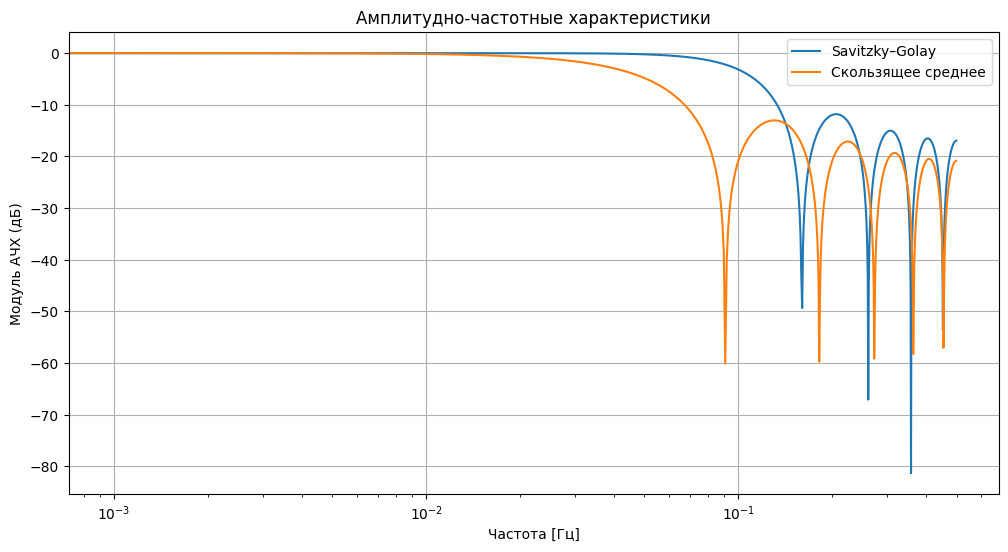

In [25]:
from scipy.signal import freqz, savgol_coeffs

window_length = 11
polyorder = 2
coeffs = savgol_coeffs(window_length, polyorder)
coeffs = coeffs / np.sum(coeffs)   # нормировка

# Ваш код здесь: вычислить АЧХ через freqz для coeffs и для скользящего среднего
coeffs_ma = np.ones(window_length) / window_length

w_savgol, H_savgol = freqz(coeffs)
w_ma, H_ma = freqz(coeffs_ma)

# Построить на одном графике (логарифмический масштаб)
plt.figure(figsize=(12, 6))
plt.semilogx(w_savgol / (2 * np.pi), 20 * np.log10(np.abs(H_savgol)), label='Savitzky–Golay')
plt.semilogx(w_ma / (2 * np.pi), 20 * np.log10(np.abs(H_ma)), label='Скользящее среднее')
plt.title('Амплитудно-частотные характеристики')
plt.xlabel('Частота [Гц]')
plt.ylabel('Модуль АЧХ (дБ)')
plt.grid(True)
plt.legend()
plt.show()

**Вопрос:** Чем отличается АЧХ Savitzky–Golay от АЧХ скользящего среднего? Как это объясняет сохранение формы сигнала?


**Ответ:** Savitzky–Golay имеет более плавный спад на высоких частотах, это позволяет лучше сохранять форму сигнала. Скользящее среднее сильнее подавляет высокочастотные составляющие.


АЧХ скользящего среднего падает резко на высоких частотах, что приводит к сильному подавлению высокочастотных составляющих, размытию сигнала и падению амплитуды.
АЧХ Savitzky–Golay падает более плавно, поэтому сохраняет больше деталей сигнала.

### Задание 3.4. Фильтрация меандра

Сгенерируйте меандр частотой 2 Гц (fs=500 Гц) и добавьте синусоидальную помеху 50 Гц амплитудой 0.5. Примените Savitzky–Golay (window=15, polyorder=3) и скользящее среднее (window=15). Сравните, как подавляется помеха и сохраняются фронты.


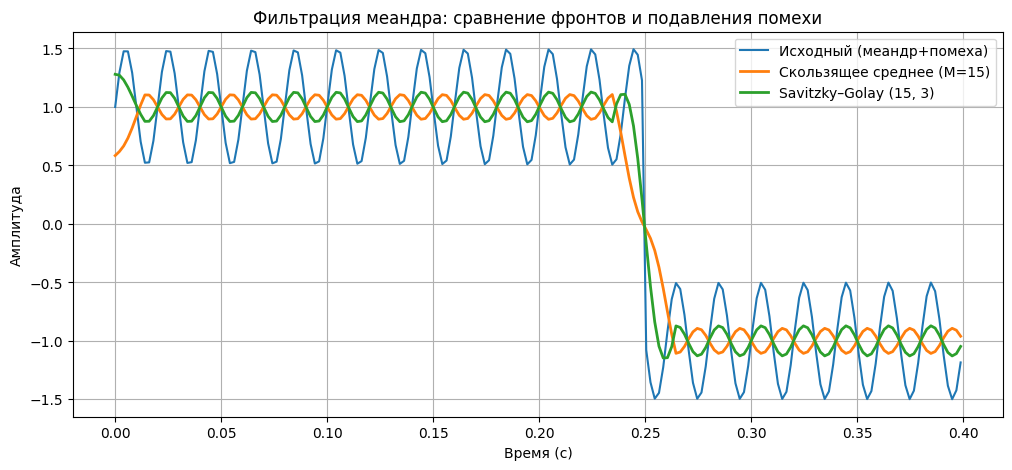

In [29]:
fs = 500
t = np.linspace(0, 1, fs)
meander = signal.square(2*np.pi*2*t)
interference = 0.5 * np.sin(2*np.pi*50*t)
x_meander = meander + interference

# Ваш код здесь: фильтрация
b_ma = np.ones(15) / 15
y_ma_meander = np.convolve(x_meander, b_ma, mode='same')

y_sg_meander = savgol_filter(x_meander, window_length=15, polyorder=3)

plt.figure(figsize=(12,5))
plt.plot(t[:200], x_meander[:200], label='Исходный (меандр+помеха)')
# Ваш код здесь: добавить графики отфильтрованных сигналов
plt.plot(t[:200], y_ma_meander[:200], label='Скользящее среднее (M=15)', linewidth=2)
plt.plot(t[:200], y_sg_meander[:200], label='Savitzky–Golay (15, 3)', linewidth=2)
plt.title('Фильтрация меандра: сравнение фронтов и подавления помехи')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Какой фильтр лучше подходит для обработки сигналов с резкими фронтами? Почему?


**Ответ:** Savitzky–Golay фильтр лучше подходит для обработки сигналов с резкими фронтами, потому что он сохраняет форму сигнала и меньше искажает его, в отличие от скользящего среднего, которое может округлять резкие переходы между уровнями. При одинаковым window=15 оба фильтра подавляют высокочастотную помеху, так как она значительно выше частоты самого меандра


## Часть 4. Сравнение КИХ и БИХ фильтров

Для скользящего среднего (`M=10`), экспоненциального фильтра (`α=0.2`) и Savitzky–Golay (`win=11, polyorder=2`):

1. Постройте на одном графике их АЧХ (в дБ) и групповую задержку.
2. Подайте на них единичный импульс и единичный скачок, постройте реакции.
3. Сгенерируйте сигнал из прямоугольных импульсов с шумом (как в примере ниже) и примените все три фильтра. Оцените качество подавления шума и сохранения фронтов.


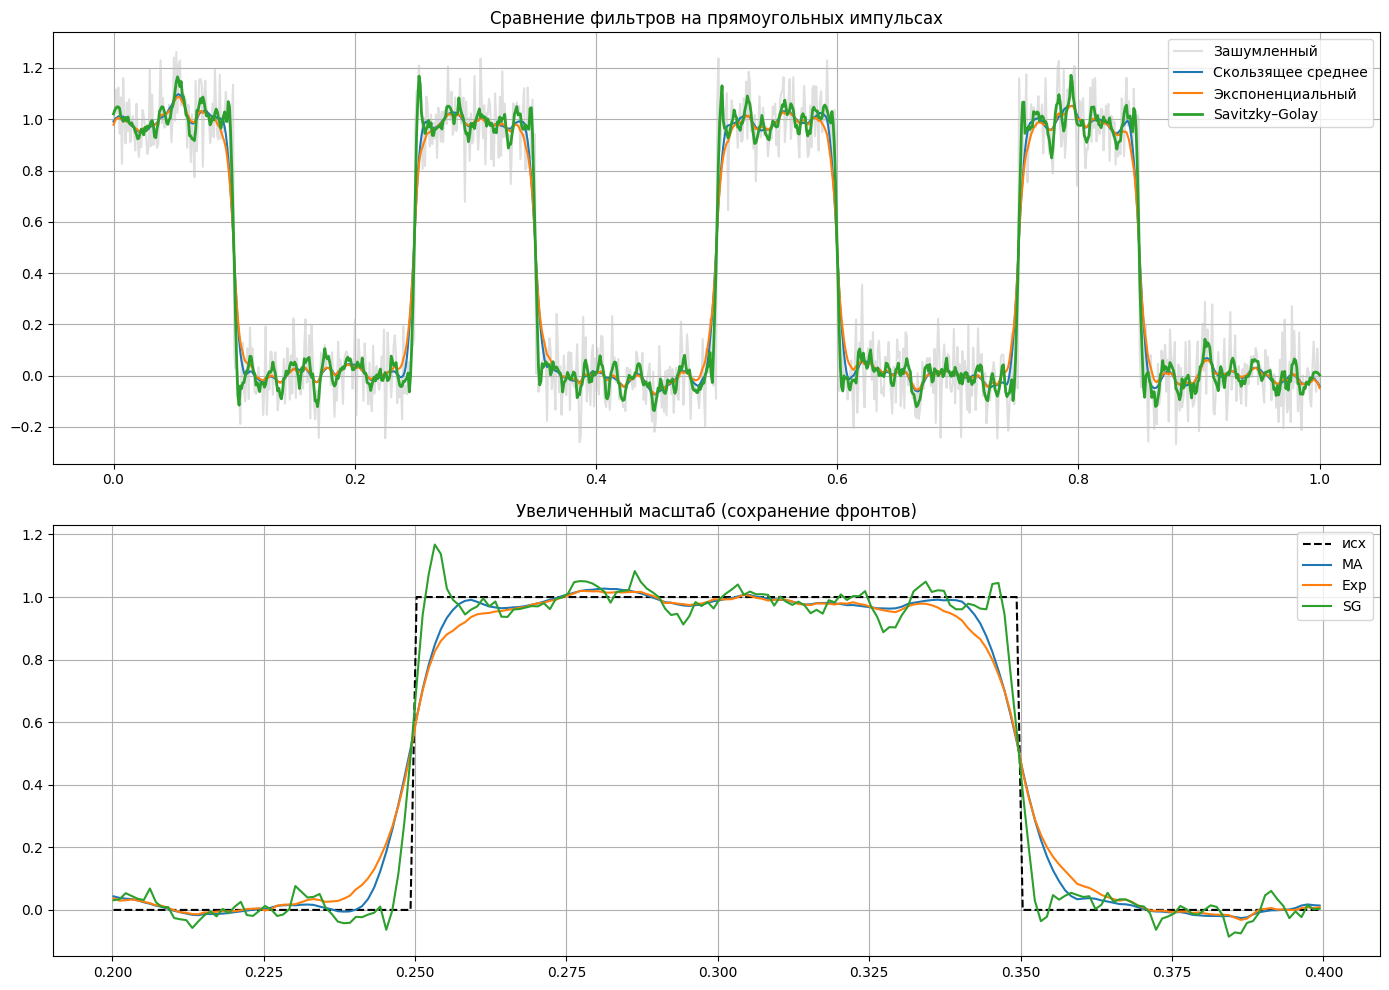

In [36]:
from scipy.signal import freqz, savgol_filter, filtfilt
# Сигнал с прямоугольными импульсами
fs = 1000
t = np.linspace(0, 1, fs)
pulse_train = np.zeros_like(t)
pulse_train[0:100] = 1
pulse_train[250:350] = 1
pulse_train[500:600] = 1
pulse_train[750:850] = 1
noise = 0.1 * np.random.randn(len(t))
x_pulse_noisy = pulse_train + noise

# Ваш код здесь: определить коэффициенты фильтров (M=10, alpha=0.2, sg coeffs)
b_ma = np.ones(10) / 10
a_ma = [1]

alpha = 0.2
b_exp = [alpha]
a_exp = [1, -(1 - alpha)]

# Ваш код здесь: отфильтровать x_pulse_noisy каждым фильтром
x_ma = signal.filtfilt(b_ma, a_ma, x_pulse_noisy)
x_exp = signal.filtfilt(b_exp, a_exp, x_pulse_noisy)
x_sg = signal.savgol_filter(x_pulse_noisy, window_length=11, polyorder=2)

# Ваш код здесь: построить графики (исходный + три отфильтрованных)
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(t, x_pulse_noisy, color='silver', alpha=0.5, label='Зашумленный')
plt.plot(t, x_ma, label='Скользящее среднее', linewidth=1.5)
plt.plot(t, x_exp, label='Экспоненциальный', linewidth=1.5)
plt.plot(t, x_sg, label='Savitzky–Golay', linewidth=2)
plt.title('Сравнение фильтров на прямоугольных импульсах')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t[200:400], pulse_train[200:400], 'k--', label='исх')
plt.plot(t[200:400], x_ma[200:400], label='MA')
plt.plot(t[200:400], x_exp[200:400], label='Exp')
plt.plot(t[200:400], x_sg[200:400], label='SG')
plt.title('Увеличенный масштаб (сохранение фронтов)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Вопрос:** Какой фильтр обеспечивает наилучшее подавление шума? Какой лучше сохраняет фронты? Какой имеет наименьшие фазовые искажения?


**Ответ:** Наилучшее подавление шума скользящее среднее. На графике видно более гладкое плато между фронтами

Лучше сохраняет фронты Savitzky–Golay, так как он использует полиномиальную аппроксимацию, лучше воспроизводя резкие переходы в сигнале.


Наименьшие фазовые искажения Savitzky–Golay, он обладает строго линейной фазовой характеристикой. При использовании savgol_filter обработка идет симметрично, что дает нулевой фазовый сдвиг